#Logistic Regression


the purpose of this notebook is to implement logistic regression to recognize if a image of a number is 1 or 0

In [24]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import math
    from sklearn.metrics import precision_score, recall_score
except ModuleNotFoundError as e:
    %pip install numpy pandas matplotlib scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


importing data


In [3]:
df_train = pd.read_csv('../content/sample_data/mnist_train_small.csv')
df_test = pd.read_csv('../content/sample_data/mnist_test.csv')

slicing dataframes into X and Y with only 1's and 0's rows

In [4]:
X_train = df_train.to_numpy()
Y_train = X_train[:,0]
X_train = X_train[:,1:]
X_train = X_train[(Y_train == 0) | (Y_train == 1)]
Y_train = Y_train[(Y_train == 0) | (Y_train == 1)]
X_train.shape, Y_train.shape

((4205, 784), (4205,))

In [5]:
X_test = df_test.to_numpy()
Y_test = X_test[:,0]
X_test = X_test[:,1:]
X_test = X_test[(Y_test == 0) | (Y_test == 1)]
Y_test = Y_test[(Y_test == 0) | (Y_test == 1)]
X_test.shape, Y_test.shape

((2115, 784), (2115,))

normalization:


In [6]:
X_train = X_train/255
X_test = X_test/255

visualizing some example images from X

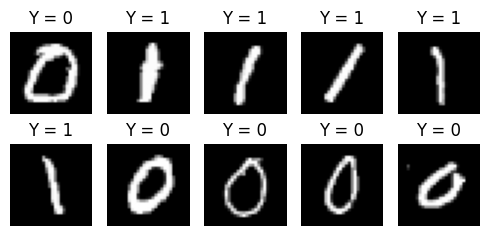

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(5,2.5))
axes = axes.flatten()

for i in range(10):

    img = X_train[i].reshape(28, 28)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Y = {Y_train[i]}')
    axes[i].set_axis_off() # Clean up the look
plt.tight_layout()
plt.show()

##Sigmoid Function

the model for logistic regression is represented as:

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$

where function $g$ is the sigmoid function:

$$g(z) = \frac{1}{1+e^{-z}}$$


In [8]:
def predict(W, b, X):

  z = np.dot(X, W) + b
  f_wb = sigmoid(z)

  return f_wb

In [9]:
def sigmoid(z):
  g = 1 / (1+(np.exp(-z)))

  return g

In [10]:
sigmoid(0)

np.float64(0.5)

##Cost function

as in linear regression, we also have to calculate the cost for logistic regression. The cost function is defined by:

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] $$




  
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single row:

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) $$
    
the goal is to minimize this function, that represents a measure of error of our model





In [11]:
def compute_cost(X, y, w, b, *argv):
    m = X.shape[0]

    z = np.dot(X, w) + b
    f_wb = sigmoid(z)


    loss = -y * np.log(f_wb) - (1 - y) * np.log(1 - f_wb)
    total_cost = np.sum(loss) / m
    return total_cost

calculando o custo inicial

In [12]:
m, n = X_train.shape

# Compute and display cost with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train, Y_train, initial_w, initial_b)
print('Cost at initial w and b (zeros): {:.3f}'.format(cost))

Cost at initial w and b (zeros): 0.693


##Gradient Descent

the gradient descent allow us to minimize the cost of the model.

the gradient descent algorithm is:


$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & b := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \newline       \; & w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \  \; & \text{for j := 0..n-1}\newline & \rbrace\end{align*}$$

where, parameters $b$, $w_j$ are all updated simultaniously, and:

$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)}
$$

In [13]:
def compute_derivatives(X, y, w, b, *argv):
    m, n = X.shape
    z = np.dot(X, w) + b
    f_wb = sigmoid(z)

    error = f_wb - y

    dj_dw = np.dot(X.T, error) / m
    dj_db = np.sum(error) / m

    return dj_db, dj_dw

In [18]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_):


    m = len(X)

    J_history = []
    w_history = []
    last_cost = 0
    for i in range(num_iters):

        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)

        w_in = w_in - alpha * dj_dw
        b_in = b_in - alpha * dj_db

        if i<100000:      # prevent resource exhaustion
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.5f}   ")
        if i>0 and abs(J_history[-1] - last_cost) < 1e-8:
            print(f"Convergence reached at iteration {i:4}: Cost {float(J_history[-1]):8.5f}   ")
            break
    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

Running GD:

In [19]:
np.random.seed(1)
initial_w = 0.01 * (np.random.rand(n) - 0.5)
initial_b = -8

iterations = 5000
alpha = 0.1

w,b, J_history,_ = gradient_descent(X_train ,Y_train, initial_w, initial_b,
                                   compute_cost, compute_derivatives, alpha, iterations, 0)


Iteration    0: Cost  3.42135   
Iteration  500: Cost  0.01824   
Iteration 1000: Cost  0.01256   
Iteration 1500: Cost  0.01024   
Iteration 2000: Cost  0.00887   
Iteration 2500: Cost  0.00792   
Iteration 3000: Cost  0.00719   
Iteration 3500: Cost  0.00660   
Iteration 4000: Cost  0.00611   
Iteration 4500: Cost  0.00569   
Iteration 4999: Cost  0.00532   


##Testing and evaluating the model

In [16]:

y_hat_test = predict(w, b, X_test)
y_pred = (y_hat_test >= 0.5).astype(int)
accuracy = np.mean(y_pred == Y_test)

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 99.81%


## Precision and Recall

**Precision**  
Measures how many of the model’s predicted positives are actually correct:



$$
\text{Precision} = \frac{TP}{TP + FP}
$$

High precision = few false positives.

**Recall (Sensitivity)**  
Measures how many of the actual positives were correctly identified by the model:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

High recall = few false negatives.


In [ ]:

print("Precision:", precision_score(Y_test, y_pred))
print("Recall:", recall_score(Y_test, y_pred))

Precision: 0.9982378854625551
Recall: 0.9982378854625551


Here we can see the examples where our model is making mistakes

Errors: 4


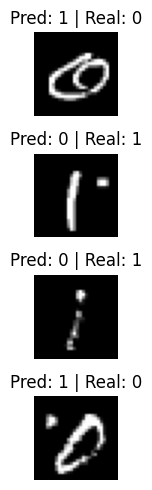

In [29]:

y_hat_test = predict(w, b, X_test)
y_pred = (y_hat_test >= 0.5).astype(int)


errors = (y_pred != Y_test)

error_indices = np.where(errors)[0]

print(f"Errors: {len(error_indices)}")

num_images = len(error_indices)
num_images = min(num_images, len(error_indices))

# Plot
fig, axes = plt.subplots(num_images, 1, figsize=(10,5))
axes = axes.flatten()

for i in range(num_images):
    idx = error_indices[i]

    img = X_test[idx].reshape(28, 28)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Pred: {y_pred[idx]} | Real: {Y_test[idx]}")
    axes[i].set_axis_off()

plt.tight_layout()
plt.show()